<a href="https://colab.research.google.com/github/Isabela-Tellez/BootcampIA/blob/main/07.%20Julio-06/Support_Vector_Machines_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Aprendizaje Supervisado:  SVM (Máquinas de Vector Soporte)

### Módulo III — Machine Learning

## 🎯 Objetivos de la sesión

Al terminar esta sesión serás capaz de:

* Identificar y explicar, en sus propias palabras, las etapas de un proceso de Machine Learning (desde la definición del problema hasta el monitoreo en producción), reconociendo en qué momento del flujo se ubican el preprocesamiento, el escalado, la división train/test, el entrenamiento y la evaluación del modelo.

* Usar scikit-learn y Máquinas de Vector Soporte (SVM) para clasificar datos


# ¿Por qué es importante SVM en Machine Learning?

SVM fue durante años uno de los algoritmos "estrella" del machine learning clásico, y sigue siendo
muy relevante en varios escenarios concretos.

## Por qué es importante

- **Funciona muy bien en espacios de alta dimensión.** Cuando tienes muchas características (como las
  9 variables celulares del dataset de cáncer), SVM sigue siendo efectivo incluso cuando el número de
  características se acerca o supera al número de muestras — algo que a otros algoritmos les cuesta más.
- **El margen máximo lo hace robusto.** Al buscar "la calle más ancha" entre clases, tiende a
  generalizar mejor que un clasificador que solo traza cualquier línea separadora, reduciendo el
  riesgo de overfitting.
- **El kernel trick es su superpoder.** Le permite resolver problemas no lineales (como el de los
  círculos concéntricos) sin tener que calcular explícitamente esa transformación a más dimensiones —
  matemáticamente es muy elegante y computacionalmente eficiente.
- **Es eficiente en memoria.** El modelo final solo depende de los "vectores de soporte" (los puntos
  más cercanos a la frontera), no de todo el dataset.
- **Funciona bien con datasets pequeños o medianos**, justo donde las redes neuronales suelen quedarse
  cortas por falta de datos.
## Cuándo se usa en la práctica

| Caso de uso | Por qué encaja con SVM |
|---|---|
| **Clasificación de células / diagnóstico médico** | Pocas muestras, muchas características, márgenes de decisión claros entre benigno/maligno |
| **Detección de spam / clasificación de texto** | Datos de alta dimensión (miles de palabras como características) y frontera relativamente clara |
| **Reconocimiento de escritura a mano y clasificación de imágenes simples** | Buen rendimiento con datasets moderados antes de que las redes convolucionales dominaran esta tarea |
| **Bioinformática** (clasificación de genes, tipos de tumor, secuencias) | Mismo patrón que el cáncer: pocas muestras, muchas variables |
| **Detección de rostros** | Clasificación binaria (cara / no cara) con buena separación de clases |
| **Scoring crediticio / detección de fraude** | Necesitas fronteras de decisión robustas y explicables, no solo "caja negra" |


En esta sesión usaremos SVM (Máquinas de Vector Soporte) para construir y entrenar un modelo con registros de células humanas, y clasificar esas células según si la muestra es benigna o maligna.

SVM funciona proyectando los datos a un espacio de características de mayor dimensión, de forma que
los puntos puedan separarse en categorías incluso cuando no son separables con una simple línea recta.
Se busca un separador entre las categorías y los datos se transforman de tal manera que ese separador
pueda dibujarse como un hiperplano. A partir de ahí, las características de un nuevo dato pueden usarse
para predecir a qué grupo debería pertenecer.


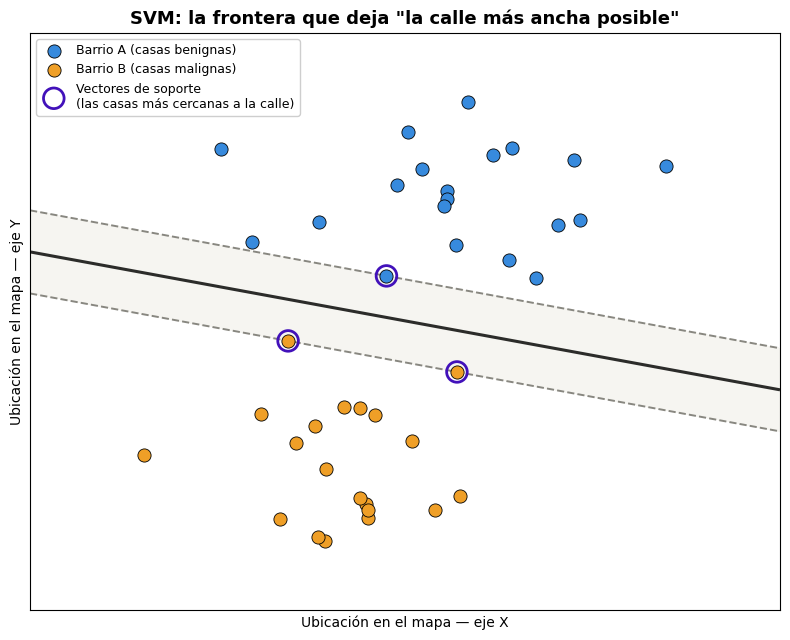

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

np.random.seed(6)
X, y = make_blobs(n_samples=40, centers=2, cluster_std=1.15, random_state=6)

clf = SVC(kernel='linear', C=1000)
clf.fit(X, y)

fig, ax = plt.subplots(figsize=(8, 6.5))

ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#378ADD', s=90, edgecolor='k',
           linewidth=0.6, label='Barrio A (casas benignas)', zorder=3)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#EF9F27', s=90, edgecolor='k',
           linewidth=0.6, label='Barrio B (casas malignas)', zorder=3)

xx = np.linspace(X[:, 0].min() - 1.5, X[:, 0].max() + 1.5, 200)
yy = np.linspace(X[:, 1].min() - 1.5, X[:, 1].max() + 1.5, 200)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='#2C2C2A', levels=[0], linestyles='-', linewidths=2.2)
ax.contour(XX, YY, Z, colors='#888780', levels=[-1, 1], linestyles='--', linewidths=1.4)
ax.contourf(XX, YY, Z, levels=[-1, 1], colors=['#F1EFE8'], alpha=0.6, zorder=1)

ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
           s=220, facecolors='none', edgecolors='#4211BA', linewidth=2,
           label='Vectores de soporte\n(las casas más cercanas a la calle)', zorder=4)

ax.set_title('SVM: la frontera que deja "la calle más ancha posible"', fontsize=13, fontweight='bold')
ax.set_xlabel("Ubicación en el mapa — eje X")
ax.set_ylabel("Ubicación en el mapa — eje Y")
ax.legend(loc='upper left', fontsize=9, framealpha=0.95)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 🧩 Reto de investigación: Las etapas de un proceso de Machine Learning
### Todos los equipos

**Contexto:** Antes de entrenar cualquier modelo, es fundamental entender que el algoritmo (KNN, SVM, árboles, etc.) es solo **una pieza** dentro de un proceso mucho más grande. Un modelo entrenado sin las etapas previas y posteriores bien hechas, difícilmente sirve en un entorno real.

### Consigna

En equipo, investiguen y respondan las siguientes preguntas:

1. ¿Cuáles son las etapas principales de un proceso de Machine Learning, desde que se define el problema de negocio hasta que el modelo está en producción? Ordénenlas de forma lógica.

2. Para cada etapa, expliquen en 1-2 líneas **qué se hace** y **por qué es necesaria**. Como mínimo, deben cubrir:
   - Definición del problema y recolección de datos
   - Preprocesamiento de datos (limpieza, tratamiento de nulos, codificación, escalado)
   - División en train/test (y validación, si aplica)
   - Entrenamiento del modelo
   - Evaluación del modelo (métricas)
   - Ajuste de hiperparámetros
   - Despliegue / puesta en producción
   - Monitoreo y reentrenamiento

3. ¿Qué pasaría si se saltan el paso de preprocesamiento y entrenan el modelo directamente con los datos "crudos"? Den un ejemplo concreto con alguno de los algoritmos que ya conocen (por ejemplo, KNN o SVM).

4. ¿En qué etapa del proceso ubicarían el escalado de variables? ¿Y la división en train/test?




<h1>Tabla de contenido de la sesión</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#load_dataset">Primeros pasos: Cargar los datos del dataset "cell_samples"</a></li>
        <li><a href="#load_dataset">Preprocesamiento y selección de datos</a></li>
        <li><a href="#load_dataset">Conjunto de entrenamiento y prueba : Modelado</a></li>
        <li><a href="#evaluation">Evaluación del modelo</a></li>
    </ol>
</div>
<br>
<hr>


## 🔵  **Equipo 1**
### Primeros pasos: Dataset cell_samples


A continuación, en equipos, deben interpretar qué hace cada una de las siguientes celdas de código y explicárselo al resto del grupo **con sus propias palabras**.

Para cada celda, respondan:
- ¿Qué hace esta celda? (en una frase, sin tecnicismos)
- ¿Por qué es necesaria en este punto del proceso?

In [ ]:
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy
%matplotlib inline

In [ ]:
# ATENCIÓN: explicar qué hace cada línea de código y, en el caso de sklearn ¿qué funciones llama y por qué?
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt

<h2 id="load_dataset">Cargar los datos de cáncer</h2>
El ejemplo se basa en un dataset disponible públicamente en el UCI Machine Learning Repository
(Asuncion and Newman, 2007)[http://mlearn.ics.uci.edu/MLRepository.html]. El dataset contiene varios
cientos de registros de muestras de células humanas, cada uno con los valores de un conjunto de
características celulares. Los campos de cada registro son:

|Nombre del campo|Descripción|
|--- |--- |
|ID|Grosor del grupo celular (clump)|
|Clump|Grosor del grupo celular|
|UnifSize|Uniformidad del tamaño de la célula|
|UnifShape|Uniformidad de la forma de la célula|
|MargAdh|Adhesión marginal|
|SingEpiSize|Tamaño de célula epitelial única|
|BareNuc|Núcleos desnudos|
|BlandChrom|Cromatina blanda|
|NormNucl|Nucléolos normales|
|Mit|Mitosis|
|Class|Benigno o maligno|

<br>
<br>


In [ ]:
#Click here and press Shift+Enter
!wget -O cell_samples.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/cell_samples.csv

### 🩺 ¿Qué acabamos de descargar?

Explicar y poner en contexto al resto del equipo acerca del Dataset y sus características, y cuál será la variable objetivo "Class" (la que determinará si es maligna o beninga)

>  Si cada fila de esta tabla fuera el historial de una biopsia real de un paciente:

*   ¿qué estaría haciendo un patólogo al rellenar las columnas Clump, UnifSize,UnifShape...?
*   Y la columna Class, ¿de dónde saldría ese valor y para qué la vamos a usar cuando entrenemos el modelo?"


## Cargamos los datos desde el archivo CSV


In [ ]:
cell_df = pd.read_csv("cell_samples.csv")
cell_df.head(15)

Explicar lo siguiente:
> El campo ID contiene el identificador de cada paciente. Las características de las muestras de células de cada paciente están en los campos de Clump a Mit. Los valores están graduados de 1 a 10, donde 1 es lo más cercano a benigno.

- El campo Class contiene el diagnóstico, confirmado mediante otro procedimiento médico independiente, sobre si la muestra es benigna (valor = 2) o maligna (valor = 4).



De la siguiente gráfica, deberán entender, interpretar y poder explicar lo siguiente:



1.   ¿Qué patrón general se observa entre el grosor del grupo celular (Clump), el tamaño uniforme (UnifSize) y el color (benigno/maligno)?
2.   ¿Encontramos puntos que "no encajen" con ese patrón? ¿Podríaos trazar una única línea recta que separe perfectamente los rojos de los verdes?
3.   Este gráfico solo usa 2 de las 9 características del dataset. ¿Por qué creemos que el modelo real no se conforma con solo estas 2?
4. ¿Cuál sería la interpretación "insight" final de este gráfico?


In [ ]:
ax = cell_df[cell_df['Class'] == 4][0:50].plot(kind='scatter', x='Clump', y='UnifSize', color='DarkRed', label='malignant');
cell_df[cell_df['Class'] == 2][0:50].plot(kind='scatter', x='Clump', y='UnifSize', color='Green', label='benign', ax=ax);
plt.show()

---
#### Fin del equipo 1

----------------------------





## ⚪   **Equipo 2**
## **Preprocesamiento y selección de datos**

A continuación, en equipos, deben interpretar qué hace cada una de las siguientes celdas de código y explicárselo al resto del grupo **con sus propias palabras** (no leyendo el código literalmente).

Para cada celda, respondan:
- ¿Qué hace esta celda? (en una frase, sin tecnicismos)
- ¿Por qué es necesaria en este punto del proceso?



Primero, veamos e interpretemos los tipos de datos de las columnas:


In [ ]:
cell_df.dtypes

Parece que la columna **BareNuc** incluye algunos valores que no son numéricos. Podemos eliminar
esas filas: ¿por qué?


In [ ]:
cell_df = cell_df[pd.to_numeric(cell_df['BareNuc'], errors='coerce').notnull()]
cell_df['BareNuc'] = cell_df['BareNuc'].astype('int')
cell_df.dtypes

### 🧹 ¿Por qué limpiar los datos primero?




### ¿qué hace la siguiente celda de código?

In [ ]:
#Interpretar y entender las siguientes líneas de código para después explicarlas
feature_df = cell_df[['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc', 'BlandChrom', 'NormNucl', 'Mit']]
X = np.asarray(feature_df)
X[0:5]

Queremos que el modelo prediga el valor de Class (es decir, benigno (=2) o maligno (=4)).


In [ ]:
#Interpretar y entender las siguientes líneas de código para después explicarlas
y = np.asarray(cell_df['Class'])
y [0:5]

-------
Fin del equipo 2



--------

## 🟢 **Equipo 3**
## **Conjunto de entrenamiento y de prueba (Train/Test)**


A continuación, en equipos, deben interpretar qué hace cada una de las siguientes celdas de código y explicárselo al resto del grupo **con sus propias palabras** (no leyendo el código literalmente).

Para cada celda, respondan:
- ¿Qué hace esta celda? (en una frase, sin tecnicismos)
- ¿Por qué es necesaria en este punto del proceso?


Dividimos nuestro dataset en un conjunto de entrenamiento y uno de prueba:
¿Por qué y cómo hacemos esa separación?



* **Train (entrenamiento)**: ¿qué datos irán aquí? y qué porcentaje?
* **Test (prueba)**: ¿qué datos irán aquí? y qué porcentaje?



In [ ]:
#Interpretar y entender las siguientes líneas de código para después explicarlas
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (546, 9) (546,)
Test set: (137, 9) (137,)


<h2 id="modeling">Modelado (SVM con Scikit-learn)</h2>


El algoritmo SVM ofrece varias funciones de kernel para realizar su procesamiento. En esencia,
proyectar los datos a un espacio de mayor dimensión se llama "kernelling". La función matemática usada
para esa transformación se conoce como función kernel, y puede ser de distintos tipos, como:

    1. Lineal
    2. Polinómica
    3. Función de base radial (RBF)  🔴Explicar y centrarse sólo en esta
    4. Sigmoide

Cada una de estas funciones tiene sus propias características, ventajas e inconvenientes, y no hay una
forma sencilla de saber de antemano cuál funcionará mejor con un dataset concreto. Normalmente se
prueban varias funciones por turnos y se comparan los resultados. Para este laboratorio usaremos la
que viene por defecto, RBF (Radial Basis Function), siendo esta última la que deberán explicar al resto de equipo.


### 🪄 El "truco" del kernel, con canicas
Pueden buscar la analogía de el truco del kernel con canicas en SVM para explicarlo mejor al resto de equipos


In [ ]:
#Interpretar y entender las siguientes líneas de código para después explicarlas
from sklearn import svm
clf = svm.SVC(kernel='rbf')
clf.fit(X_train, y_train)

SVC()

Una vez entrenado, el modelo puede usarse para predecir valores nuevos:


In [ ]:
yhat = clf.predict(X_test)
yhat [0:5]

array([2, 4, 2, 4, 2])

--------

## 🟢 **Equipo 4**


A continuación, en equipos, deben interpretar qué hace cada una de las siguientes celdas de código y explicárselo al resto del grupo **con sus propias palabras** (no leyendo el código literalmente).

Para cada celda, respondan:
- ¿Qué hace esta celda? (en una frase, sin tecnicismos)
- ¿Por qué es necesaria en este punto del proceso?



## **Evaluación del modelo**


¿qué hace la siguiente función y por qué es importante en esta etapa del proceso?

In [ ]:
#Interpretar y entender las siguientes líneas de código para después explicarlas

from sklearn.metrics import classification_report, confusion_matrix
import itertools

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.

    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

### 🧩 Matriz de confusión:


Interpretar y explicar correctamente la matriz de confusión al resto de los equipos



In [ ]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat, labels=[2,4])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat))

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Benign(2)','Malignant(4)'],normalize= False,  title='Confusion matrix')

También puedes usar fácilmente el **f1_score** de la librería sklearn:


### ⚖️ F1-score vs. índice de Jaccard, en una frase

Ambas son formas de resumir en un solo número qué tan bien clasifica el modelo, pero desde ángulos
distintos: el **F1-score** equilibra falsos positivos y falsos negativos (útil cuando ambos tipos de
error importan, como aquí). El **índice de Jaccard** mide qué tan solapadas están las predicciones
correctas de una clase concreta frente al total (aciertos + ambos tipos de error) para esa clase.
En la práctica, para este dataset, mira si ambos números se mueven en la misma dirección al cambiar
el kernel — si no, es una señal de que el modelo trata mejor a una clase que a la otra.


In [ ]:
from sklearn.metrics import f1_score
f1_score(y_test, yhat, average='weighted')

0.9639038982104676

Probemos también el índice de Jaccard como medida de exactitud:


In [ ]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat,pos_label=2)

np.float64(0.9444444444444444)

## 📚 Recursos y documentación oficial de referencia

Si quieres profundizar más allá de esta sesión, estos son los recursos oficiales donde se basa todo lo visto en este notebook:

### Documentación de scikit-learn (SVM)
- **Guía de usuario de SVM**: explicación conceptual completa (clasificación, regresión, kernels, complejidad computacional)
  https://scikit-learn.org/stable/modules/svm.html
- **Referencia de la API — `svm.SVC`**: todos los parámetros del clasificador (kernel, C, gamma...)
  https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- **Comparación visual de kernels y fronteras de decisión** (ejemplos oficiales con gráficos)
  https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html

### Métricas de evaluación usadas en este notebook
- **Matriz de confusión**: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- **F1-score**: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
- **Índice de Jaccard**: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.jaccard_score.html

### El dataset
- **UCI Machine Learning Repository — Breast Cancer Wisconsin (Original)**, la fuente original de los datos de este notebook (Asuncion and Newman, 2007)
  http://mlearn.ics.uci.edu/MLRepository.html

### Para ir más allá (opcional)
- **"An Idiot's Guide to Support Vector Machines"** (R. Berwick, MIT) — una introducción matemática accesible al concepto de margen máximo y vectores de soporte
  https://web.mit.edu/6.034/wwwbob/svm-notes-long-08.pdf